# Alexandre_Projet

Le code original de Stella Ruddy avait une license MIT, ce qui veut dire que je peux faire des modifications au code. Une licence MIT a également été utilisée pour ce projet.

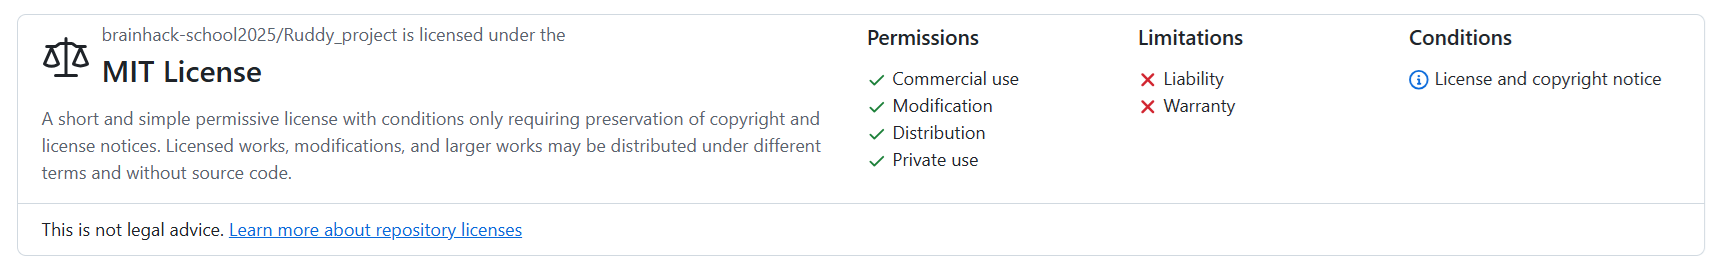

## Description du projet

Ce projet est basé sur le notebook *"Functional Brain Activation During a Memory Encoding and Retrieval Task: Discovering Tools and Techniques for Analysis"* de Stella Ruddy (2024), qui est inspiré par l'article scientifique *"Dynamic changes in neural representations underlie the repetition effect on false memory"* (Shao et al., 2022).

L'étude analyse l'activation cérébrale d'un seul participant pendant une tâche de mémoire composée de deux phases : **encodage** (9 listes de mots présentées 3 fois chacune) et **récupération** (24h plus tard). Les données IRMf proviennent du dataset OpenNeuro [ds003789](https://openneuro.org/datasets/ds003789/versions/2.1.0). Un modèle linéaire général (GLM) est appliqué pour comparer l'activation neuronale entre la première (rep1) et la troisième (rep3) présentation des listes.

>Ce notebook contient la structure du repository, comment utiliser/démarer l'automatisation du notebook, les tâches accomplies, les problèmes associées et les améliorations/limitations.


## Structure du repository

```
Alexandre_Projet/
├── Alexandre_Final.ipynb           # Notebook principal
├── environnement_false_memory.yml  # Environnement conda reproductible
├── tasks.py                        # Script d'automatisation (invoke)
├── documentation_projet.ipynb      # Documentation de tout mon processus de codage
├── LICENSE                         # Licence MIT
└── README.ipynb                    # Description du projet et de mes tâches
```

## Utilisation de l'expérience

### 1. Cloner le repository
```bash
git clone https://github.com/psy3019-6973-2026/Alexandre_Projet.git
cd Alexandre_Projet
```

### 2. Exécuter tous les notebook de façon automatisé
```bash
pip install invoke              # Nécessaire pour l'automatisation avec invoke
invoke setup                    # Crée l'environnement
conda activate false_memory     # Activation de l'environnement
invoke fetch                    # Télécharge les données OpenNeuro
invoke run                      # Exécute le notebook principal automatiquement
```

Ou en commande plus courte :
```bash
pip install invoke
invoke setup 
conda activate false_memory
invoke all
```

<div style="background-color:#8e2be4b8; padding:10px; border-left:4px solid #00000000;">
⚠️ <b>Attention</b> — Écrire toutes ces commandes une à la suite de l'autre dans un terminal Ubuntu.
</div>


<div style="background-color:#8e2be4b8; padding:10px; border-left:4px solid #00000000;">
⚠️ <b>Attention</b> — L'automatisation de tout le notebook peut durer entre 1h30 et 2h.
</div>


# Tâche 1: Reproductibilité et infrastructure
Le but de cette tâche était de reproduire le notebook à partir d'un environnement vierge et de documenter le processus. Une sous-tâche était aussi d'automatiser la tâche. La proposition était de faire l'automatisation avec invoke.

## Ce qui a été accompli 
#### Tâche 1-A
- Création d'un fichier environnement yml (environnement_false_memory.yml) avec toutes les dépendances nécessaires pour rendre l'environnement reproductible sur un autre ordinateur.
- Ajouter le téléchargement automatique du dataset (ds003789) pour que l'utilisateur ne soit pas obligé de tout télécharger par lui même.
- Remplacer les chemins  des fichiers qui ne pouvaient que fonctionner sur l'ordinateur local de l'autrice et faire en sorte qu'ils peuvent fonctionner sur n'importe quel ordinateur.
- Ajouter une barre de progression tqdm pour le preprocessing des images IRMf
- Documentation du processus dans ce markdown (documentation_projet.ipynb) 

#### Tâche 1-B
- Automatisation de la tâche avec invoke dans le fichier tasks.py. La tâche peut s'activer à partir d'un terminal Ubuntu.

### Problèmes rencontrés

| # | Problème | Solution |
|---|----------|---------|
| A | Aucun accès au repository initial | Envoyer un courriel à l'auteure du projet |
| B | Chemins de fichiers spécifiques à un seul ordinateur | Utilisation de datalad |
| C | Preprocessing long sans retour visuel | Ajout de tqdm (20-45 min) |
| D | Perte de connexion lors de l'automatisation | Rouler le code à partir d'un terminal Ubuntu |

<details>
<summary>Voir les détails</summary>

**Problème A — Aucun accès au repository initial**
- Le lien du repository Github envoyait à une page erreur 404. 
<
- En envoyant le courriel, j'ai reçu le notebook du projet. Puisque je n'avais pas accès au repository, je n'avais aucun document accessible. Il était difficile de savoir s'il me manquait certaines informations.

---

**Problème B — Chemins locaux**  
Les données (datasets) nécessaires étaient téléchargées préalablement, donc le chemin des fichiers utilisés était sur le disque local de l'autrice du notebook. Ce lien était alors spécifique à son ordinateur.  
→ Création d'URLs pour accéder au GitHub d'OpenNeuro et télécharger le dataset automatiquement avec datalad install et datalad get.  

---

**Problème C — Preprocessing sans progression visible**  
Le preprocessing incluait de mettre un high-pass, de standardiser et ensuite de mettre une filtre gaussien sur les 9 images d'IRMf (9 run). Ça faisait juste continuellement charger, ce qui pouvait laisser croire que ça ne fonctionnait pas.  
→ Ajout d'une barre de progression avec tqdm. Cette étape prend entre 20 et 45 minutes.

---

**Problème D — Perte de connexion lors de l'automatisation**
- En utilisant le terminal de VSCode, à plusieurs reprises, à la fin de l'automatisation, il y avait une perte de connexion inconnu qui empêchait toute progression possible. Elle empêchait aussi l'enregistrement, donc il fallait réécrire le tout après avoir redémarré l'ordinateur. La seule solution trouvée fonctionnelle est d'utiliser la procédure d'automatisation dans un terminal Ubuntu et de s'assurer que VSCode est fermé.

---



**Grandes difficultés rencontrées**
- Adapter les données avec l'information de l'exercice 4 (fichiers) pour que ce soit cohérent avec le reste du notebook.
- Les wildcards (*) ne fonctionnent pas avec os.path.join. Résolu en passant le chemin directement en string avec pathlib.

</details>

## Tâche 2 — Adaptation à un nouveau participant et à un nouveau jeu de données

Le but original était de reproduire le notebook à partir d'une autre base de données. Il m'a d'abord été proposé de commencer par le changement entre les participants du dataset original.

**Nouveau dataset :** [ds002731](https://openneuro.org/datasets/ds002731/versions/1.0.2) — *"Multiple interactive memory representations underlie the induction of false memory"* (Zhu et al., 2019)


### Ce qui a été accompli

Tâche 2-A 
- Donner la possibiliter de changer entre les participants du dataset original (ds003789) en changeant une variable (subj).

Tâche 2-B : Adapter le notebook à un autre dataset
- Téléchargement automatique des fichiers des nouveaux participants grâce à datalad.
- **Application du contexte expérimental des deux participants du nouveau dataset au restant du notebook.** 
- Adaptation des fichiers d'événements (pas de trial_type → groupe récupéré depuis participants.tsv).
- Visualisations comparatives côte à côte : images anatomiques, IRMf moyennes, masques cérébraux.
- Contrastes adaptés (dummy vs baseline au lieu de rep1 vs rep3).
- Cartes d'activation (beta maps, z-maps) générées pour les deux sujets.
- Correction pour comparaisons multiples appliquée (seuil non corrigé, Bonferroni, FDR, test F).
- Tableaux de clusters significatifs extraits pour les deux sujets.

Extra :
- Documentation du processus dans ce markdown (documentation_projet.ipynb).
- Ajouter des commentaires au notebook pour le rendre compréhensiblle.
- Automatisation de la tâche avec invoke dans le fichier tasks.py.



### Problèmes rencontrés

| # | Problème | Solution |
|---|----------|---------|
| A | Pas de colonne trial_type dans le nouveau dataset | Récupération du groupe à partir du document participants.tsv |
| B | Contraste rep1 vs rep3 non applicable | Contraste dummy vs baseline |
| C | Coordonnées différentes entre les deux sujets | Coordonnées MNI moyennes communes + « standardisation » |

<details>
<summary>Voir les détails</summary>


**Problème A — Pas de trial_type**  
Les fichiers TSV du nouveau dataset ne contiennent pas de colonne trial_type nécessaire pour définir les conditions rep1/rep2/rep3.  
→ Après lecture de l'article, les conditions (AV, VV, AA, VA) sont définies au niveau du participant dans participants.tsv. Adaptation du code pour comparer deux sujets de groupes différents (visual-visual vs audio-visual).

---

**Problème B — Contraste non applicable**  
Le contraste rep1 vs rep3 n'est pas applicable puisqu'il n'y a pas de conditions de répétition.  
→ Utilisation du contraste dummy vs baseline + comparaison visuelle des deux sujets côte à côte.

---

**Problème C — Coordonnées incohérentes**  
Les deux sujets avaient des coordonnées différentes, rendant la comparaison visuelle incohérente.  
→ Calcul de coordonnées MNI moyennes entre les deux sujets.
→ Coordonnées MNI (0, 0, 0) pour les deux sujets.


---

**Grandes difficultés rencontrées**
- Comprendre pourquoi trial_type n'existait pas.
- Le design de la tâche (expected fMRI signal) n'est pas applicable au nouveau dataset.
- Décider quelles parties du notebook original garder ou modifier.


</details>

### Limites/améliorations prioritaires :

- Les coordonnées (0, 0, 0) permettent une comparaison intuitive entre les sujets (but de l'article), mais ne montrent pas nécessairement les régions les plus activées.
- Le code contient de la duplication pour les deux sujets. Une amélioration serait d'utiliser une boucle.

https://nbviewer.org/github/psy3019-6973-2026/Alexandre_Projet/blob/main/Alexandre_Final.ipynb

## Utilisation de l'intelligence artificielle

L'IA a été utilisée pour :
- Comprendre certaines librairies de neuroimagerie quand la documentation n'était pas suffisante.
- Déboguer les erreurs liées aux chemins de fichiers.
- Comprendre la structure du nouveau dataset (ds002731)
- Améliorer certains textes explicatifs dans le notebook
- Aider avec le script d'automatisation « tasks.py » avec « invoke »
- Comprendre les commandes « git » pour créer une nouvelle branche